# Student 3 — Defect Detection
## Notebook 04: Model comparison and benchmark

**Purpose.** This notebook assembles the results of the three detectors into the comparison
required by Section 4.1 (Experimental Results) and Section 4.2 (Discussion) of the assignment
documentation, and checks them against the SMART objectives of Section 1.2.

It does **no training** — it only reads the JSON files written by notebooks 01–03:

```
results/yolov10.json      <- 01_yolov10_training.ipynb
results/faster_rcnn.json  <- 02_faster_rcnn_training.ipynb
results/rtdetr.json       <- 03_rtdetr_training.ipynb
```

All figures are exported to `results/figures/` as 300 dpi PNGs, and the comparison table is
exported as `results/model_comparison.csv` so it can be pasted straight into the report.

### 1. Load the results

Any model whose JSON is missing is skipped with a warning, so the notebook still runs if only one
or two of the three have been trained so far.

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")


def find_work_dir(start: Path) -> Path:
    for c in [start, *start.parents]:
        if (c / "results").is_dir() or (c / "dataset" / "dataset_info.json").is_file():
            return c
        if (c / "Student3-Defect Detection" / "results").is_dir():
            return c / "Student3-Defect Detection"
    raise FileNotFoundError("Could not locate the Student3-Defect Detection folder.")

WORK_DIR    = find_work_dir(Path.cwd())
RESULTS_DIR = WORK_DIR / "results"
FIG_DIR     = RESULTS_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED = [("yolov10.json", "YOLOv10"),
            ("faster_rcnn.json", "Faster R-CNN"),
            ("rtdetr.json", "RT-DETR")]

results = {}
for fname, label in EXPECTED:
    path = RESULTS_DIR / fname
    if path.is_file():
        results[label] = json.loads(path.read_text())
        print(f"loaded  {fname}")
    else:
        print(f"MISSING {fname} - run the corresponding notebook to include {label}")

assert results, "No result files found - train at least one model first."

loaded  yolov10.json
loaded  faster_rcnn.json
loaded  rtdetr.json


### 2. Plotting style

One fixed colour per model, used identically in every figure so that a reader never has to re-learn
the legend. The three hues are colour-vision-deficiency safe as a set, and the grid is kept
recessive so the bars carry the message.

In [2]:
MODEL_COLORS = {           # fixed slots - a model keeps its colour in every chart
    "YOLOv10":      "#2a78d6",
    "Faster R-CNN": "#eb6834",
    "RT-DETR":      "#1baf7a",
}
MODEL_ORDER = [label for _, label in EXPECTED if label in results]
INK, MUTED  = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": MUTED,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "font.size": 10,
})


def save(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path)
    print("saved", path.name)

print("Models in this comparison:", MODEL_ORDER)

Models in this comparison: ['YOLOv10', 'Faster R-CNN', 'RT-DETR']


### 3. Master comparison table

Accuracy is reported on the **test** split, which no model saw during training or model selection.
Latency and FPS were measured one image at a time on the same hardware within each notebook — note
the `device` column, because a CPU figure and a GPU figure must never be compared directly.

In [3]:
rows = []
for m in MODEL_ORDER:
    r = results[m]; t = r["test"]
    rows.append({
        "Model":        r["model"],
        "Variant":      r["variant"],
        "Type":         r["type"],
        "Params (M)":   r["params_M"],
        "Epochs":       r["epochs"],
        "Device":       r["device"],
        "Precision":    round(t["precision"], 4),
        "Recall":       round(t["recall"], 4),
        "F1":           round(t["f1"], 4),
        "mAP@0.5":      round(t["mAP50"], 4),
        "mAP@0.5:0.95": round(t["mAP50_95"], 4),
        "Latency (ms)": r["latency_ms"],
        "FPS":          r["fps"],
        "Train (min)":  r["train_time_min"],
    })

df = pd.DataFrame(rows).set_index("Model")
df.to_csv(RESULTS_DIR / "model_comparison.csv")
print("saved", (RESULTS_DIR / "model_comparison.csv").name)
df

saved model_comparison.csv


,Variant,Type,Params (M),Epochs,Device,Precision,Recall,F1,mAP@0.5,mAP@0.5:0.95,Latency (ms),FPS,Train (min)
Model,,,,,,,,,,,,,
YOLOv10,yolov10n,single-stage (NMS-free),2.78,20,CPU,0.5652,0.5274,0.5457,0.5665,0.2491,52.13,19.2,37.37
Faster R-CNN,fasterrcnn_resnet50_fpn_v2_smallanchors,"two-stage (RPN + RoIAlign, with NMS)",43.28,3,CPU,0.7143,0.1645,0.2674,0.4669,0.1640,2612.09,0.4,182.18
RT-DETR,rtdetr-l,end-to-end transformer (NMS-free),32.97,10,CPU,0.7010,0.6371,0.6676,0.6694,0.2932,482.63,2.1,161.25


### 4. Detection accuracy

`mAP@0.5` answers "was the defect found?"; `mAP@0.5:0.95` additionally penalises loose boxes and is
therefore the stricter, more informative number for defects only ~10–25 px across. Each bar is
labelled directly, so the figure is readable without consulting the axis.

saved accuracy_comparison.png


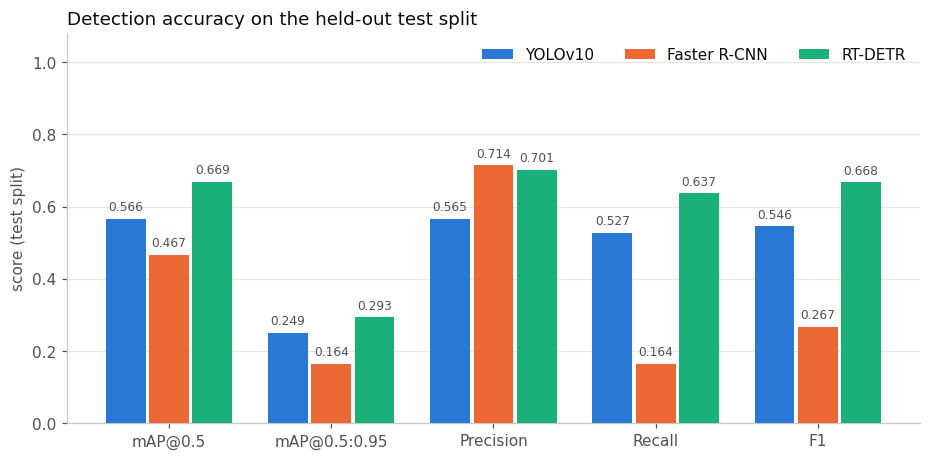

In [4]:
metrics = [("mAP50", "mAP@0.5"), ("mAP50_95", "mAP@0.5:0.95"), ("precision", "Precision"),
           ("recall", "Recall"), ("f1", "F1")]
x = np.arange(len(metrics))
w = 0.8 / len(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(10, 4.6))
for i, m in enumerate(MODEL_ORDER):
    vals = [results[m]["test"][k] for k, _ in metrics]
    pos = x + (i - (len(MODEL_ORDER) - 1) / 2) * w
    ax.bar(pos, vals, w * 0.92, label=m, color=MODEL_COLORS[m], zorder=3)
    for p, v in zip(pos, vals):
        ax.text(p, v + 0.015, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=MUTED)

ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in metrics])
ax.set_ylim(0, 1.08); ax.set_ylabel("score (test split)")
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.set_title("Detection accuracy on the held-out test split", loc="left", fontsize=12)
ax.legend(frameon=False, ncol=len(MODEL_ORDER))
save(fig, "accuracy_comparison"); plt.show()

### 5. Inference speed

Latency and throughput are two views of the same measurement, so they are plotted as two separate
panels rather than on a shared twin axis. The dashed line marks the 30 FPS requirement stated in
Objective 1.

saved speed_comparison.png


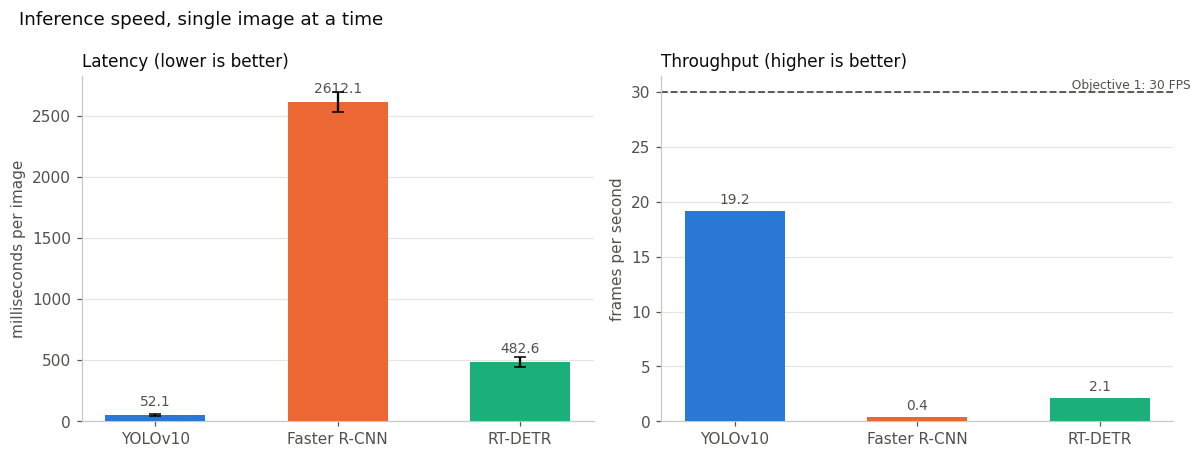

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

lat = [results[m]["latency_ms"] for m in MODEL_ORDER]
err = [results[m].get("latency_std_ms", 0) for m in MODEL_ORDER]
ax[0].bar(MODEL_ORDER, lat, 0.55, yerr=err, capsize=4,
          color=[MODEL_COLORS[m] for m in MODEL_ORDER], zorder=3)
for i, v in enumerate(lat):
    ax[0].text(i, v + max(lat) * 0.02, f"{v:.1f}", ha="center", va="bottom", fontsize=9, color=MUTED)
ax[0].set_ylabel("milliseconds per image"); ax[0].yaxis.grid(True, zorder=0); ax[0].set_axisbelow(True)
ax[0].set_title("Latency (lower is better)", loc="left", fontsize=11)

fps = [results[m]["fps"] for m in MODEL_ORDER]
ax[1].bar(MODEL_ORDER, fps, 0.55, color=[MODEL_COLORS[m] for m in MODEL_ORDER], zorder=3)
for i, v in enumerate(fps):
    ax[1].text(i, v + max(fps) * 0.02, f"{v:.1f}", ha="center", va="bottom", fontsize=9, color=MUTED)
ax[1].axhline(30, ls="--", lw=1.2, color=MUTED)
ax[1].text(len(MODEL_ORDER) - 0.5, 30, "  Objective 1: 30 FPS", va="bottom", ha="right",
           fontsize=8, color=MUTED)
ax[1].set_ylabel("frames per second"); ax[1].yaxis.grid(True, zorder=0); ax[1].set_axisbelow(True)
ax[1].set_title("Throughput (higher is better)", loc="left", fontsize=11)

fig.suptitle("Inference speed, single image at a time", x=0.02, ha="left", fontsize=12)
plt.tight_layout(); save(fig, "speed_comparison"); plt.show()

### 6. The accuracy / speed trade-off

This is the figure that carries the argument of Section 4.2: the ideal detector sits in the
**top-right** corner (fast and accurate). Marker area is proportional to model size, which makes
the third dimension of the trade-off — parameter count, and therefore memory and cost — visible in
the same view.

saved accuracy_vs_speed.png


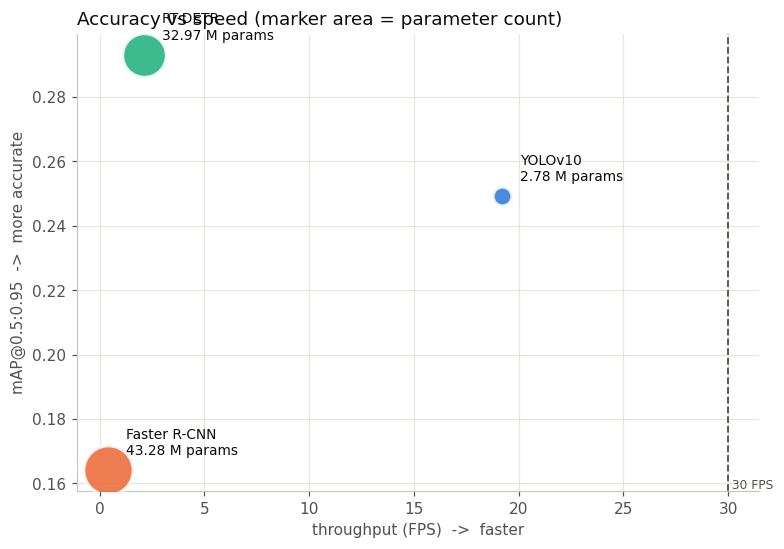

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.4))
for m in MODEL_ORDER:
    r = results[m]
    ax.scatter(r["fps"], r["test"]["mAP50_95"], s=r["params_M"] * 22 + 90,
               color=MODEL_COLORS[m], alpha=.85, edgecolor="white", linewidth=2, zorder=3)
    ax.annotate(f"{m}\n{r['params_M']} M params",
                (r["fps"], r["test"]["mAP50_95"]),
                textcoords="offset points", xytext=(12, 10), fontsize=9, color=INK)

ax.axvline(30, ls="--", lw=1.2, color=MUTED)
ax.text(30, ax.get_ylim()[0], " 30 FPS", fontsize=8, color=MUTED, va="bottom")
ax.set_xlabel("throughput (FPS)  ->  faster")
ax.set_ylabel("mAP@0.5:0.95  ->  more accurate")
ax.grid(True, zorder=0); ax.set_axisbelow(True)
ax.set_title("Accuracy vs speed (marker area = parameter count)", loc="left", fontsize=12)
save(fig, "accuracy_vs_speed"); plt.show()

### 7. Per-class comparison

Where the models differ per defect type is the most useful evidence for the discussion chapter: a
model that is only average overall but clearly best on `open_circuit` and `mouse_bite` — the two
thin, low-contrast defects — may still be the right choice for a specific production line.

saved per_class_comparison.png


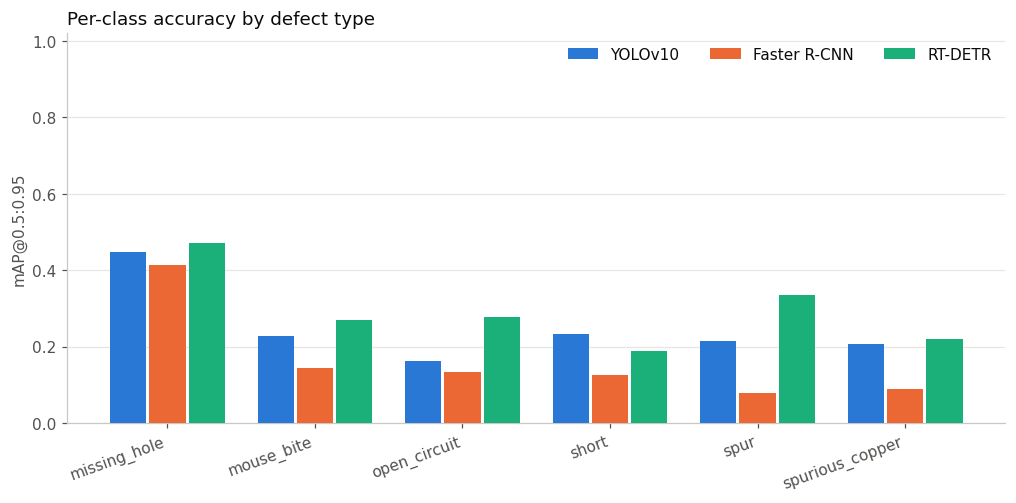

,YOLOv10,Faster R-CNN,RT-DETR
missing_hole,0.449,0.412,0.470
mouse_bite,0.228,0.144,0.269
open_circuit,0.163,0.133,0.277
short,0.234,0.127,0.189
spur,0.216,0.079,0.335
spurious_copper,0.205,0.089,0.219


In [7]:
all_classes = sorted({c for m in MODEL_ORDER for c in results[m]["per_class"]})
x = np.arange(len(all_classes))
w = 0.8 / len(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(11, 4.6))
for i, m in enumerate(MODEL_ORDER):
    vals = [results[m]["per_class"].get(c, {}).get("mAP50_95", np.nan) for c in all_classes]
    ax.bar(x + (i - (len(MODEL_ORDER) - 1) / 2) * w, vals, w * 0.92,
           label=m, color=MODEL_COLORS[m], zorder=3)
ax.set_xticks(x); ax.set_xticklabels(all_classes, rotation=20, ha="right")
ax.set_ylim(0, 1.02); ax.set_ylabel("mAP@0.5:0.95")
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.set_title("Per-class accuracy by defect type", loc="left", fontsize=12)
ax.legend(frameon=False, ncol=len(MODEL_ORDER))
save(fig, "per_class_comparison"); plt.show()

pc = pd.DataFrame({m: {c: results[m]["per_class"].get(c, {}).get("mAP50_95", np.nan)
                       for c in all_classes} for m in MODEL_ORDER}).round(3)
pc.to_csv(RESULTS_DIR / "per_class_comparison.csv")
pc

### 8. Objective check

The three SMART objectives from Section 1.2 are evaluated mechanically against the measured
numbers. Note that Objective 2 is stated as "99 % detection accuracy" — read here as mAP@0.5 on the
test split, which is the strictest reasonable reading. State the interpretation explicitly in the
report rather than letting the metric be ambiguous.

In [8]:
best_acc   = max(MODEL_ORDER, key=lambda m: results[m]["test"]["mAP50_95"])
best_speed = max(MODEL_ORDER, key=lambda m: results[m]["fps"])

print("OBJECTIVE CHECK (test split)\n" + "-" * 62)
print(f"Obj 1  >= 30 FPS")
for m in MODEL_ORDER:
    ok = "MET    " if results[m]["fps"] >= 30 else "NOT MET"
    print(f"   {ok}  {m:<14} {results[m]['fps']:>7.1f} FPS   ({results[m]['device']})")

print(f"\nObj 2  >= 0.99 mAP@0.5")
for m in MODEL_ORDER:
    v = results[m]["test"]["mAP50"]
    ok = "MET    " if v >= 0.99 else "NOT MET"
    print(f"   {ok}  {m:<14} {v:>7.4f} mAP@0.5")

print(f"\nObj 3  batch of 100 boards inside a 1-minute window")
for m in MODEL_ORDER:
    secs = 100 * results[m]["latency_ms"] / 1000
    ok = "MET    " if secs <= 60 else "NOT MET"
    print(f"   {ok}  {m:<14} {secs:>7.1f} s for 100 images")

print("\n" + "-" * 62)
print(f"Most accurate : {best_acc} (mAP@0.5:0.95 = {results[best_acc]['test']['mAP50_95']:.4f})")
print(f"Fastest       : {best_speed} ({results[best_speed]['fps']:.1f} FPS)")

OBJECTIVE CHECK (test split)
--------------------------------------------------------------
Obj 1  >= 30 FPS
   NOT MET  YOLOv10           19.2 FPS   (CPU)
   NOT MET  Faster R-CNN       0.4 FPS   (CPU)
   NOT MET  RT-DETR            2.1 FPS   (CPU)

Obj 2  >= 0.99 mAP@0.5
   NOT MET  YOLOv10         0.5665 mAP@0.5
   NOT MET  Faster R-CNN    0.4669 mAP@0.5
   NOT MET  RT-DETR         0.6694 mAP@0.5

Obj 3  batch of 100 boards inside a 1-minute window
   MET      YOLOv10            5.2 s for 100 images
   NOT MET  Faster R-CNN     261.2 s for 100 images
   MET      RT-DETR           48.3 s for 100 images

--------------------------------------------------------------
Most accurate : RT-DETR (mAP@0.5:0.95 = 0.2932)
Fastest       : YOLOv10 (19.2 FPS)


### 9. Auto-generated summary for the report

A plain-text paragraph built from the measured numbers, written to
`results/comparison_summary.md`. Use it as the factual skeleton of Sections 4.2 and 5.1 — then
rewrite it in your own words and in UK English, as the documentation requires.

In [9]:
lines = ["# Defect detection - model comparison summary", "",
         f"Dataset: Clean_Dataset (6 PCB defect classes), evaluated on the held-out test split.", ""]
lines.append("| Model | Type | Params (M) | mAP@0.5 | mAP@0.5:0.95 | Precision | Recall | FPS | Device |")
lines.append("|---|---|---|---|---|---|---|---|---|")
for m in MODEL_ORDER:
    r = results[m]; t = r["test"]
    lines.append(f"| {r['model']} | {r['type']} | {r['params_M']} | {t['mAP50']:.3f} | "
                 f"{t['mAP50_95']:.3f} | {t['precision']:.3f} | {t['recall']:.3f} | "
                 f"{r['fps']:.1f} | {r['device']} |")
lines += ["", "## Findings", "",
          f"- Highest accuracy: **{best_acc}** with mAP@0.5:0.95 = "
          f"{results[best_acc]['test']['mAP50_95']:.3f} and mAP@0.5 = "
          f"{results[best_acc]['test']['mAP50']:.3f}.",
          f"- Highest throughput: **{best_speed}** at {results[best_speed]['fps']:.1f} FPS "
          f"({results[best_speed]['latency_ms']:.1f} ms per image).",
          f"- Accuracy spread across the three architectures: "
          f"{max(results[m]['test']['mAP50_95'] for m in MODEL_ORDER) - min(results[m]['test']['mAP50_95'] for m in MODEL_ORDER):.3f} mAP@0.5:0.95.",
          f"- Hardest defect class overall: "
          f"{min(all_classes, key=lambda c: np.nanmean([results[m]['per_class'].get(c, {}).get('mAP50_95', np.nan) for m in MODEL_ORDER]))}.",
          f"- Easiest defect class overall: "
          f"{max(all_classes, key=lambda c: np.nanmean([results[m]['per_class'].get(c, {}).get('mAP50_95', np.nan) for m in MODEL_ORDER]))}.",
          "", "Figures for the report are in `results/figures/`."]

summary = "\n".join(lines)
(RESULTS_DIR / "comparison_summary.md").write_text(summary, encoding="utf-8")
print(summary)

# Defect detection - model comparison summary

Dataset: Clean_Dataset (6 PCB defect classes), evaluated on the held-out test split.

| Model | Type | Params (M) | mAP@0.5 | mAP@0.5:0.95 | Precision | Recall | FPS | Device |
|---|---|---|---|---|---|---|---|---|
| YOLOv10 | single-stage (NMS-free) | 2.78 | 0.566 | 0.249 | 0.565 | 0.527 | 19.2 | CPU |
| Faster R-CNN | two-stage (RPN + RoIAlign, with NMS) | 43.28 | 0.467 | 0.164 | 0.714 | 0.164 | 0.4 | CPU |
| RT-DETR | end-to-end transformer (NMS-free) | 32.97 | 0.669 | 0.293 | 0.701 | 0.637 | 2.1 | CPU |

## Findings

- Highest accuracy: **RT-DETR** with mAP@0.5:0.95 = 0.293 and mAP@0.5 = 0.669.
- Highest throughput: **YOLOv10** at 19.2 FPS (52.1 ms per image).
- Accuracy spread across the three architectures: 0.129 mAP@0.5:0.95.
- Hardest defect class overall: spurious_copper.
- Easiest defect class overall: missing_hole.

Figures for the report are in `results/figures/`.
